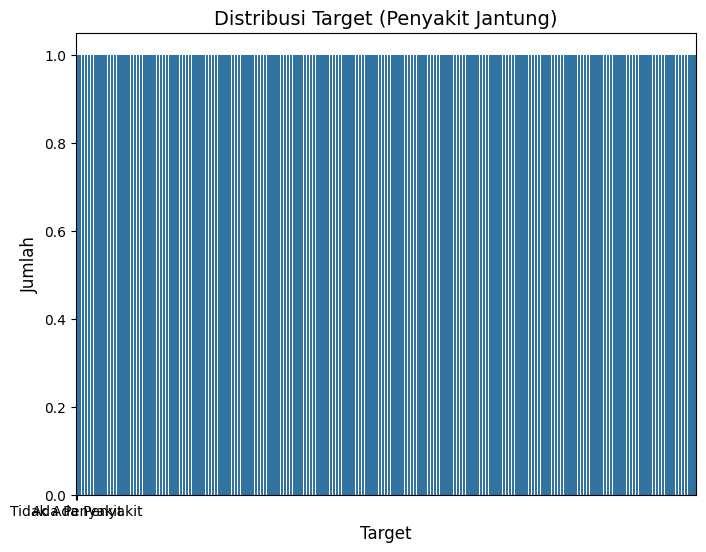

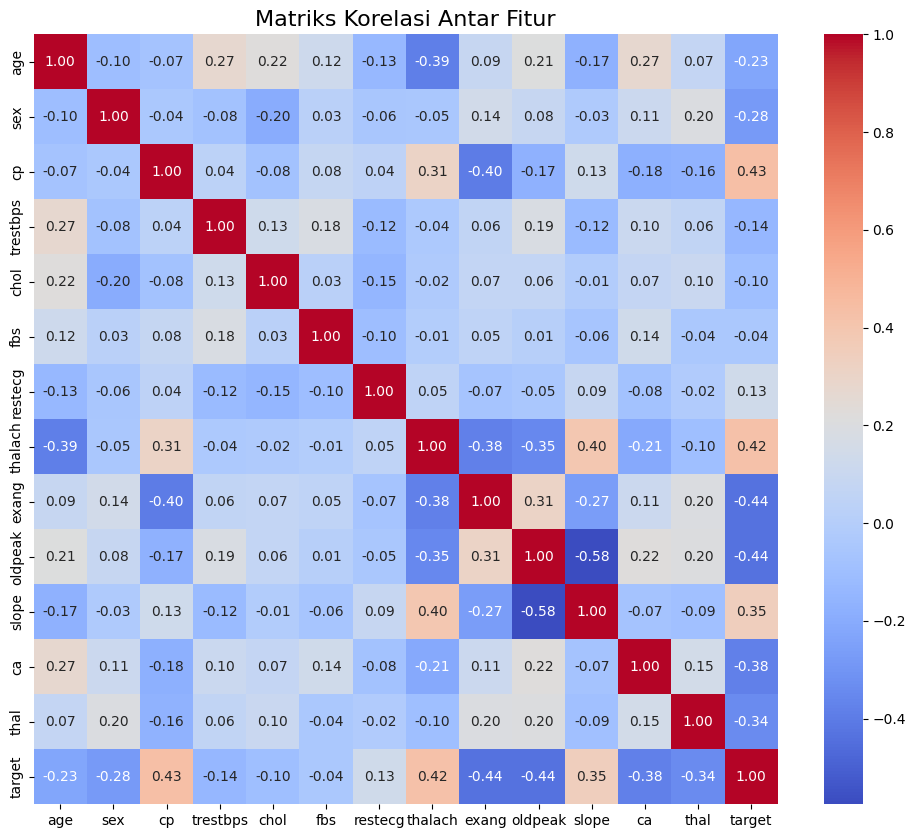

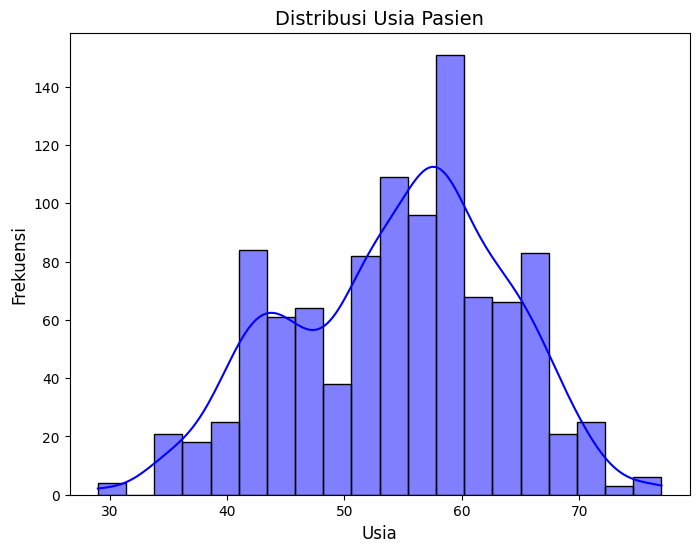

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import itertools
import time

# Membaca dataset
data = pd.read_csv('/content/sample_data/heart.csv')

# Exploratory Data Analysis (EDA)
# Distribusi target
plt.figure(figsize=(8, 6))
sns.countplot(data['target'])
plt.title('Distribusi Target (Penyakit Jantung)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Tidak Ada Penyakit', 'Ada Penyakit'])
plt.show()

# Korelasi antar fitur
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriks Korelasi Antar Fitur', fontsize=16)
plt.show()

# Distribusi usia pasien
plt.figure(figsize=(8, 6))
sns.histplot(data['age'], kde=True, bins=20, color='blue')
plt.title('Distribusi Usia Pasien', fontsize=14)
plt.xlabel('Usia', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

In [ ]:
# Preprocessing Data
# Membagi data menjadi fitur (X) dan target (y)
X = data.drop(columns=['target'])
y = data['target']

# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Membagi dataset menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Mengonversi data ke tensor PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Membuat DataLoader
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

In [ ]:
# Membangun Model Multilayer Perceptron (MLP)
class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, activation_fn):
        super(MLPModel, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activation_fn)
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 2))  # Output layer
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
# Fungsi pelatihan dan evaluasi
def train_and_evaluate(hidden_layers, activation_fn, epochs, learning_rate, batch_size):
    train_loader, test_loader = create_dataloaders(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, batch_size)

    model = MLPModel(input_size=X_train.shape[1], hidden_sizes=hidden_layers, activation_fn=activation_fn)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

    # Evaluasi
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / total
    return accuracy

In [ ]:
# Kombinasi hyperparameter
hidden_layer_options = [[4],[8],[16], [8, 4],[16,32], [16, 8, 4]]
activation_options = [nn.ReLU(), nn.Sigmoid(), nn.Tanh()]
epoch_options = [25, 50, 100, 250]
learning_rate_options = [10, 1, 0.01, 0.001, 0.0001]
batch_size_options = [16, 32, 64, 128, 256]

results = []

In [ ]:
# Mencoba semua kombinasi hyperparameter
for i, (hidden_layers, activation_fn, epochs, learning_rate, batch_size) in enumerate(itertools.product(
    hidden_layer_options, activation_options, epoch_options, learning_rate_options, batch_size_options)):

    print(f"Processing combination {i + 1}: {hidden_layers, activation_fn, epochs, learning_rate, batch_size}")
    start_time = time.time()

    try:
        accuracy = train_and_evaluate(hidden_layers, activation_fn, epochs, learning_rate, batch_size)
        results.append({
            'hidden_layers': hidden_layers,
            'activation_fn': activation_fn.__class__.__name__,
            'epochs': epochs,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'accuracy': accuracy
        })
        print(f"Combination {i + 1} completed in {time.time() - start_time:.2f} seconds with accuracy: {accuracy:.4f}")
    except Exception as e:
        print(f"Error with combination {i + 1}: {hidden_layers, activation_fn, epochs, learning_rate, batch_size}: {e}")

Processing combination 1: ([4], ReLU(), 25, 10, 16)
Combination 1 completed in 2.40 seconds with accuracy: 0.4927
Processing combination 2: ([4], ReLU(), 25, 10, 32)
Combination 2 completed in 0.68 seconds with accuracy: 0.6780
Processing combination 3: ([4], ReLU(), 25, 10, 64)
Combination 3 completed in 0.41 seconds with accuracy: 0.4878
Processing combination 4: ([4], ReLU(), 25, 10, 128)
Combination 4 completed in 0.29 seconds with accuracy: 0.6439
Processing combination 5: ([4], ReLU(), 25, 10, 256)
Combination 5 completed in 0.25 seconds with accuracy: 0.6585
Processing combination 6: ([4], ReLU(), 25, 1, 16)
Combination 6 completed in 1.24 seconds with accuracy: 0.5171
Processing combination 7: ([4], ReLU(), 25, 1, 32)
Combination 7 completed in 0.70 seconds with accuracy: 0.7268
Processing combination 8: ([4], ReLU(), 25, 1, 64)
Combination 8 completed in 0.44 seconds with accuracy: 0.8000
Processing combination 9: ([4], ReLU(), 25, 1, 128)
Combination 9 completed in 0.36 secon

     hidden_layers activation_fn  epochs  learning_rate  batch_size  accuracy
835           [16]          Tanh      50           0.01          16       1.0
1285      [16, 32]          ReLU     250           0.01          16       1.0
1362      [16, 32]       Sigmoid     100           0.01          64       1.0
1361      [16, 32]       Sigmoid     100           0.01          32       1.0
1360      [16, 32]       Sigmoid     100           0.01          16       1.0


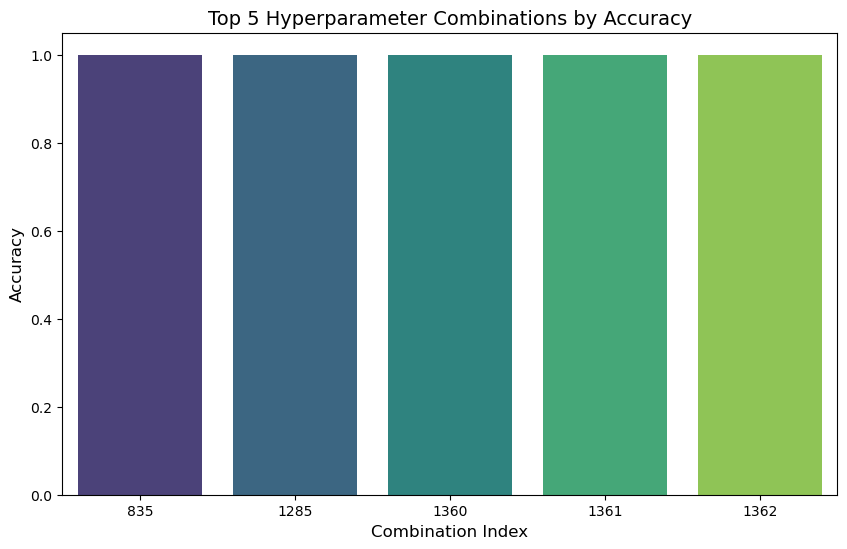

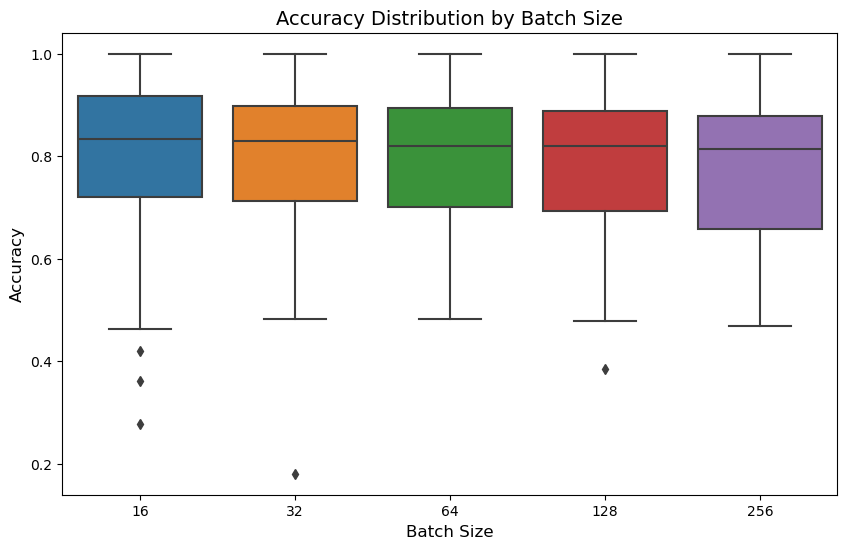

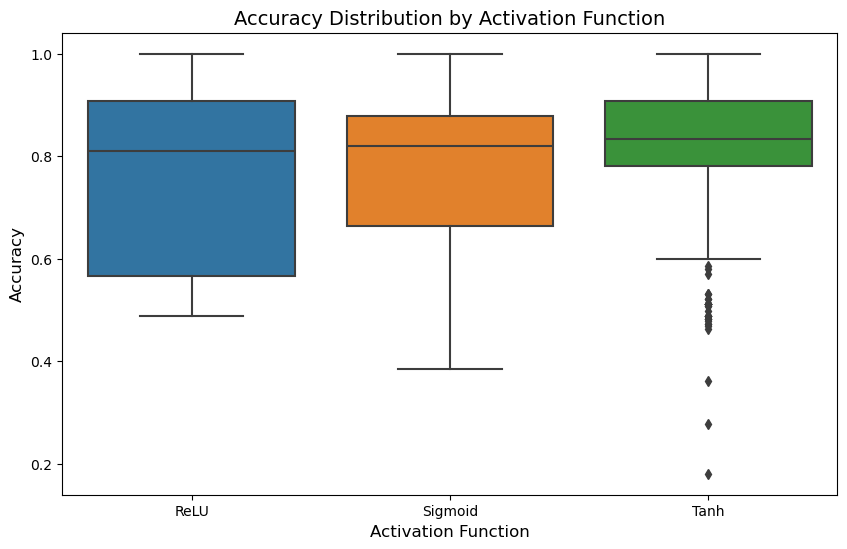

In [ ]:
# Konversi hasil ke DataFrame dan tampilkan
results_df = pd.DataFrame(results)
top_5_results = results_df.sort_values(by='accuracy', ascending=False).head(5)
print(top_5_results)

# Visualisasi hasil
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_results.index, y=top_5_results['accuracy'], palette='viridis')
plt.title('Top 5 Hyperparameter Combinations by Accuracy', fontsize=14)
plt.xlabel('Combination Index', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(x='batch_size', y='accuracy', data=results_df)
plt.title('Accuracy Distribution by Batch Size', fontsize=14)
plt.xlabel('Batch Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='activation_fn', y='accuracy', data=results_df)
plt.title('Accuracy Distribution by Activation Function', fontsize=14)
plt.xlabel('Activation Function', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.show()